The Office Hierarchy Game
The Game: "Who's the Boss?"

Setup:

5 employees work in an office: Alice, Bob, Carol, Dave, and Eve
There's a hidden organizational structure with 2-3 hierarchical levels (e.g., 1 CEO, 2 managers, 2 workers)
OR a hidden friendship structure with 2-3 social cliques
Gameplay (10 rounds):Each round, one randomly selected employee must choose:

Who to approach (pick another employee)
What to request: Either "Can you file this report?" (work order) OR "Want to grab coffee?" (social invitation)
The approached employee then decides:

Accept (thumbs up ✓)
Reject (thumbs down ✗)
Decision Rules for Employees (hidden from observer):If work order requested:

Accept with 90% probability if requester is your boss
Accept with 20% probability if requester is your peer/subordinate
If social invitation requested:

Accept with 90% probability if requester is in your friend clique
Accept with 20% probability if requester is outside your clique
Observer's Goal:
After 10 rounds, correctly identify:

The hierarchical structure (who reports to whom), OR
The friendship cliques (who is friends with whom)
Scoring:

+10 points for each correctly identified relationship
-5 points for each incorrectly identified relationship


# Interactive Partially Observable Markov Decision Processes (I-POMDPs)

An **Interactive POMDP (I-POMDP)** extends the POMDP framework to multi-agent settings by explicitly modeling other agents' beliefs, preferences, and decision-making processes. For an observer modeling employee *e*, an I-POMDP is defined as:

$$\text{I-POMDP}_o = \langle IS_o, A, T_o, \Omega_o, O_o, R_o \rangle$$

where:

**Interactive State Space (IS_o)**: $IS_o = S \times M_e$ where:
- **S**: Physical states (employee relationships, requests made, responses given)
- **M_e**: Models of employee *e*, which include:
  - *Subintentional models*: Simple behavioral models (e.g., random acceptance)
  - *Intentional models* (types): $\theta_e = \langle b_e, \tilde{\theta}_e \rangle$ where $b_e$ is employee *e*'s belief over organizational structure and $\tilde{\theta}_e$ represents *e*'s frame (preferences, observation function)

**Key Assumptions**:

1. **Model Non-Manipulability (MNM)**: The observer cannot directly change employees' beliefs about the organizational structure. Beliefs can only be influenced indirectly through observable interactions.

2. **Model Non-Observability (MNO)**: The observer cannot directly observe employees' internal beliefs about who their bosses or friends are. These must be inferred from observations of requests and responses.

**Belief Update**: The observer's belief in an I-POMDP is a probability distribution over the interactive state space $IS_o = S \times M_e$. When updating beliefs after observing interaction $o_o^t$, the observer must:

1. Predict employee *e*'s likely actions based on *e*'s model of the organizational structure
2. Update beliefs about the true organizational structure based on observed interactions
3. Update beliefs about *e*'s beliefs by reasoning about what *e* has observed and how *e* would update their understanding

For intentional models of employee *e*, the belief update involves:

$$b_o^t(is^t) = \beta \sum_{is^{t-1}} b_o^{t-1}(is^{t-1}) P(a_e^{t-1} | \theta_e^{t-1}) O_o(s^t, a^{t-1}, o_o^t) T_o(s^{t-1}, a^{t-1}, s^t)$$

where $\beta$ is a normalizing constant.

**Value Function and Solutions**: The value function for an I-POMDP is defined recursively:

$$U(\theta_o) = \max_{a_o \in A_o} \left[ \sum_{is} ER_o(is, a_o) b_o(is) + \gamma \sum_{o_o \in \Omega_o} P(o_o | a_o, b_o) U(\langle SE_{\theta_o}(b_o, a_o, o_o), \tilde{\theta}_o \rangle) \right]$$

**Finitely Nested I-POMDPs**: Since infinitely nested beliefs are not computable, we construct finitely nested I-POMDPs:
- Level 0: Models that treat other agents as having fixed behavioral patterns
- Level 1: Models other agents as level-0 agents (with beliefs over physical states only)
- Level *l*: Models other agents as having models up to level *l*-1

In our office hierarchy game, the observer uses a level-1 I-POMDP to model employees who have level-0 beliefs about the organizational structure.

# Modeling the Office Hierarchy Game as an I-POMDP

We model the Office Hierarchy Game from the observer's perspective as a level-1 I-POMDP, where the observer models employees as having level-0 beliefs about the organizational structure.

**Simplified Setting**: To keep the problem tractable, we'll focus on a 3-person office: Alice, Bob, and Carol. We'll consider two possible organizational structures:
- **Structure 0**: Alice is the boss of Bob and Carol (hierarchical: 1 manager, 2 workers)
- **Structure 1**: Bob is the boss of Alice and Carol (hierarchical: 1 manager, 2 workers)

**Interactive State Space**: $IS_o = S \times \Theta_e$ where:
- $S = \{0, 1\}$ - The two possible organizational structures
- $\Theta_e$ - Employee beliefs about the structure, characterized by $\theta_e = \langle b_e, \tilde{\theta}_e \rangle$
  - $b_e = P(\text{Structure 0})$ - Employee's belief about the structure (a probability in [0,1])
  - $\tilde{\theta}_e$ - Employee's frame (observation function, reward function) - assumed known

**Actions**:
- **For Employees**: $A_e = \{(\text{target}, \text{request\_type})\}$ where:
  - target ∈ {Alice, Bob, Carol}
  - request_type ∈ {WorkOrder, SocialInvite}
- **For Observer**: The observer is passive (no actions), just observing and updating beliefs

**Observations for Observer**: $\Omega_o = \{(\text{requester}, \text{target}, \text{request\_type}, \text{response})\}$ where:
- requester ∈ {Alice, Bob, Carol}
- target ∈ {Alice, Bob, Carol}
- request_type ∈ {WorkOrder, SocialInvite}
- response ∈ {Accept, Reject}

**Employee Decision Model** (Level-0):
Each employee has a belief $b_e$ about the organizational structure and decides:
1. Who to approach (uniformly random among other employees)
2. What to request (uniformly random between WorkOrder and SocialInvite)
3. If approached, whether to accept or reject based on their belief about relationships:
   - If WorkOrder: Accept with high probability (0.9) if requester is believed to be boss, low probability (0.2) otherwise
   - If SocialInvite: Accept with high probability (0.9) if requester is believed to be friend, low probability (0.2) otherwise

**Transition Function**: 
- The organizational structure is fixed throughout the game (no transitions)
- Employee beliefs evolve based on observations of interactions

**Observation Function for Employees**:
When employee *e* observes an interaction (requester, target, request, response), they update their belief about the structure using Bayesian inference:
- If response matches what would be expected under Structure 0 (e.g., Alice's work order accepted): increase belief in Structure 0
- If response matches what would be expected under Structure 1: increase belief in Structure 1

**Reward Function for Observer**:
- The observer accumulates information to infer the true structure
- Reward = +1 for each observation (to encourage gathering information)
- Final reward at the end = +10 * (correctness of structure inference)

**Key Insight**: The observer uses level-1 reasoning to:
1. Predict each employee's actions based on their beliefs about the structure
2. Update beliefs about both the true structure AND each employee's beliefs
3. Make inferences by reasoning: "If Alice believes she's the boss, she's more likely to give work orders. If I observe Bob accepting Alice's work order, that suggests either (a) the structure is Alice-as-boss, or (b) Bob believes Alice is the boss, or (c) it's a noisy acceptance."

This creates a rich inference problem where the observer must disentangle:
- The true organizational structure
- Each employee's beliefs about the structure
- Noise in the acceptance/rejection decisions

In [66]:
from memo import memo, domain
import jax
import jax.numpy as np

In [67]:
from enum import IntEnum

# Employees
class Employee(IntEnum):
    Alice = 0
    Bob = 1
    Carol = 2

# Organizational structures (physical states)
# Structure 0: Alice is boss of Bob and Carol
# Structure 1: Bob is boss of Alice and Carol
class Structure(IntEnum):
    AliceBoss = 0
    BobBoss = 1

# Request types
class RequestType(IntEnum):
    WorkOrder = 0
    SocialInvite = 1

# Response types
class Response(IntEnum):
    Accept = 0
    Reject = 1

# Discretized belief space for employee beliefs about structure
# b_e represents P(Structure.AliceBoss) from employee's perspective
B_e = np.linspace(0, 1, 11)  # 11 discrete belief points for computational efficiency

@jax.jit
def get_belief_e(b_e, s):
    """
    Get probability that employee assigns to structure s.
    b_e is P(AliceBoss) from employee's perspective.
    """
    belief_probs = np.array([b_e, 1.0 - b_e])
    return belief_probs[s]

@jax.jit
def is_boss_of(structure, boss, subordinate):
    """
    Check if 'boss' is the boss of 'subordinate' in the given structure.
    
    Structure 0 (AliceBoss): Alice is boss of Bob and Carol
    Structure 1 (BobBoss): Bob is boss of Alice and Carol
    """
    # Structure 0: Alice (0) is boss of Bob (1) and Carol (2)
    s0_relations = np.array([
        [0, 1, 1],  # Alice is boss of Bob, Carol
        [0, 0, 0],  # Bob is not boss of anyone
        [0, 0, 0]   # Carol is not boss of anyone
    ])
    
    # Structure 1: Bob (1) is boss of Alice (0) and Carol (2)
    s1_relations = np.array([
        [0, 0, 0],  # Alice is not boss of anyone
        [1, 0, 1],  # Bob is boss of Alice, Carol
        [0, 0, 0]   # Carol is not boss of anyone
    ])
    
    return np.where(
        structure == Structure.AliceBoss,
        s0_relations[boss, subordinate],
        s1_relations[boss, subordinate]
    )

@jax.jit
def are_friends(structure, emp1, emp2):
    """
    Check if emp1 and emp2 are friends in the given structure.
    For simplicity, we define friendship as being at the same hierarchical level.
    
    Structure 0: Bob and Carol are friends (both workers)
    Structure 1: Alice and Carol are friends (both workers)
    """
    # Structure 0: Bob (1) and Carol (2) are friends
    s0_friends = np.array([
        [0, 0, 0],  # Alice has no friends at same level
        [0, 0, 1],  # Bob is friends with Carol
        [0, 1, 0]   # Carol is friends with Bob
    ])
    
    # Structure 1: Alice (0) and Carol (2) are friends
    s1_friends = np.array([
        [0, 0, 1],  # Alice is friends with Carol
        [0, 0, 0],  # Bob has no friends at same level
        [1, 0, 0]   # Carol is friends with Alice
    ])
    
    return np.where(
        structure == Structure.AliceBoss,
        s0_friends[emp1, emp2],
        s1_friends[emp1, emp2]
    )

print("Defined state space and helper functions")

Defined state space and helper functions


In [68]:
@jax.jit
def P_accept(structure, b_e, requester, target, request_type):
    """
    Probability that target accepts requester's request, given:
    - structure: The true organizational structure
    - b_e: Target's belief about the structure P(AliceBoss)
    - requester: Who is making the request
    - target: Who is receiving the request
    - request_type: WorkOrder or SocialInvite
    
    Decision rule:
    - WorkOrder: Accept with 0.9 if requester is boss, 0.2 otherwise (based on target's belief)
    - SocialInvite: Accept with 0.9 if requester is friend, 0.2 otherwise (based on target's belief)
    """
    # Compute expected probability based on target's belief
    # P(accept | WorkOrder) = P(requester is boss | b_e) * 0.9 + P(requester not boss | b_e) * 0.2
    
    # For Structure 0 (AliceBoss), check if requester is boss of target
    is_boss_s0 = is_boss_of(Structure.AliceBoss, requester, target)
    is_friend_s0 = are_friends(Structure.AliceBoss, requester, target)
    
    # For Structure 1 (BobBoss), check if requester is boss of target
    is_boss_s1 = is_boss_of(Structure.BobBoss, requester, target)
    is_friend_s1 = are_friends(Structure.BobBoss, requester, target)
    
    # Target's expected values based on belief
    expected_is_boss = b_e * is_boss_s0 + (1 - b_e) * is_boss_s1
    expected_is_friend = b_e * is_friend_s0 + (1 - b_e) * is_friend_s1
    
    # Acceptance probabilities
    p_accept_work = expected_is_boss * 0.9 + (1 - expected_is_boss) * 0.2
    p_accept_social = expected_is_friend * 0.9 + (1 - expected_is_friend) * 0.2
    
    return np.where(
        request_type == RequestType.WorkOrder,
        p_accept_work,
        p_accept_social
    )

@jax.jit
def R_target(structure, requester, target, request_type, response):
    """
    Reward for the target employee when responding to a request.
    
    Positive reward for accepting requests from boss/friends.
    Negative reward for accepting requests from non-boss/non-friends.
    Small cost for rejecting.
    """
    is_boss = is_boss_of(structure, requester, target)
    is_friend = are_friends(structure, requester, target)
    
    # If WorkOrder and accepted
    work_accept_reward = np.where(is_boss == 1, 1.0, -1.0)
    
    # If SocialInvite and accepted
    social_accept_reward = np.where(is_friend == 1, 1.0, -1.0)
    
    # Reward for accepting
    accept_reward = np.where(
        request_type == RequestType.WorkOrder,
        work_accept_reward,
        social_accept_reward
    )
    
    # Reward structure: +reward if accept correct person, -reward if accept wrong person, -0.1 if reject
    return np.where(
        response == Response.Accept,
        accept_reward,
        -0.1  # Small cost for rejecting
    )

print("Defined action and observation functions")

Defined action and observation functions


In [69]:
@jax.jit
def bayesian_belief_update_employee(b_e_prior, structure_prior, requester, target, request_type, response):
    """
    Compute employee's posterior belief after observing an interaction.
    
    The employee observes: (requester, target, request_type, response)
    And updates their belief about which structure is true.
    
    Args:
        b_e_prior: Employee's prior belief P(AliceBoss)
        structure_prior: The actual structure (but employee doesn't know this)
        requester, target, request_type, response: Observed interaction
    
    Returns:
        Employee's posterior belief P(AliceBoss | observation)
    """
    # Likelihood: P(response | structure, requester, target, request_type)
    # This is the probability of seeing the observed response under each structure
    
    # Under Structure 0 (AliceBoss)
    is_boss_s0 = is_boss_of(Structure.AliceBoss, requester, target)
    is_friend_s0 = are_friends(Structure.AliceBoss, requester, target)
    
    p_accept_work_s0 = is_boss_s0 * 0.9 + (1 - is_boss_s0) * 0.2
    p_accept_social_s0 = is_friend_s0 * 0.9 + (1 - is_friend_s0) * 0.2
    
    p_accept_s0 = np.where(
        request_type == RequestType.WorkOrder,
        p_accept_work_s0,
        p_accept_social_s0
    )
    
    # Under Structure 1 (BobBoss)
    is_boss_s1 = is_boss_of(Structure.BobBoss, requester, target)
    is_friend_s1 = are_friends(Structure.BobBoss, requester, target)
    
    p_accept_work_s1 = is_boss_s1 * 0.9 + (1 - is_boss_s1) * 0.2
    p_accept_social_s1 = is_friend_s1 * 0.9 + (1 - is_friend_s1) * 0.2
    
    p_accept_s1 = np.where(
        request_type == RequestType.WorkOrder,
        p_accept_work_s1,
        p_accept_social_s1
    )
    
    # Likelihood for each structure given the observed response
    likelihood_s0 = np.where(response == Response.Accept, p_accept_s0, 1 - p_accept_s0)
    likelihood_s1 = np.where(response == Response.Accept, p_accept_s1, 1 - p_accept_s1)
    
    # Prior: [P(AliceBoss), P(BobBoss)]
    prior = np.array([b_e_prior, 1.0 - b_e_prior])
    
    # Likelihood: P(observation | structure)
    likelihood = np.array([likelihood_s0, likelihood_s1])
    
    # Posterior: P(structure | observation) ∝ P(observation | structure) * P(structure)
    posterior_unnorm = likelihood * prior
    posterior = posterior_unnorm / (np.sum(posterior_unnorm) + 1e-10)  # Add small epsilon for numerical stability
    
    # Return P(AliceBoss | observation)
    return posterior[0]

print("Defined belief update function")

Defined belief update function


In [70]:
from functools import cache

# Helper function to compute expected Q-value for employee response
@jax.jit
def expected_reward_for_response(b_e, requester, target, request_type, response):
    """
    Compute the expected reward for a response given employee's belief.
    This is what Q_employee would compute, but as a pure function.
    """
    # Expected reward is E_structure[R_target(structure, requester, target, request_type, response)]
    # where the expectation is over the employee's belief
    
    # For Structure 0 (AliceBoss)
    reward_s0 = R_target(Structure.AliceBoss, requester, target, request_type, response)
    # For Structure 1 (BobBoss)
    reward_s1 = R_target(Structure.BobBoss, requester, target, request_type, response)
    
    # Expected reward: b_e * reward_s0 + (1 - b_e) * reward_s1
    return b_e * reward_s0 + (1.0 - b_e) * reward_s1

print("Defined expected reward function for employees")

Defined expected reward function for employees


In [71]:
# Observer's belief space - simplified to 2 dimensions for tractability
B_o_struct = np.linspace(0, 1, 11)  # Observer's belief about true structure
B_o_bob = np.linspace(0, 1, 11)     # Observer's belief about Bob's belief

@jax.jit
def get_belief_o_struct(b_o_struct, s):
    """Observer's belief about the true structure."""
    belief_probs = np.array([b_o_struct, 1.0 - b_o_struct])
    return belief_probs[s]

@jax.jit
def get_belief_o_employee(b_o_emp, b_e):
    """Observer's belief about an employee's belief."""
    return np.exp(-50.0 * (b_e - b_o_emp)**2)

@jax.jit
def is_alice(emp):
    """Probability distribution that puts all mass on Alice."""
    return np.where(emp == Employee.Alice, 1.0, 0.0)

@jax.jit
def is_bob(emp):
    """Probability distribution that puts all mass on Bob."""
    return np.where(emp == Employee.Bob, 1.0, 0.0)

# Simplified Level-1 I-POMDP Q-function for observer
@memo(cache=True)
def Q_observer[b_o_struct: B_o_struct, b_o_bob: B_o_bob](t):
    """
    Level-1 I-POMDP value function for the observer.
    
    Simplified version: Observer tracks beliefs about structure and Bob's belief.
    Observes Alice making a request to Bob.
    """
    observer: knows(b_o_struct, b_o_bob)
    observer: thinks[
        env: knows(b_o_struct, b_o_bob),
        # Sample true structure from observer's belief
        env: chooses(structure in Structure, wpp=get_belief_o_struct(b_o_struct, structure)),
        # Sample Bob's belief from observer's model
        env: chooses(b_e_bob in B_e, wpp=get_belief_o_employee(b_o_bob, b_e_bob)),
        # Alice makes a request to Bob (deterministic)
        env: chooses(requester in Employee, wpp=is_alice(requester)),
        env: chooses(target in Employee, wpp=is_bob(target)),
        # Request type is chosen uniformly
        env: chooses(request_type in RequestType, wpp=1.0),
        # Bob responds based on his belief (softmax over expected rewards)
        env: chooses(response in Response, wpp=exp(
            expected_reward_for_response(b_e_bob, requester, target, request_type, response)
        ))
    ]
    observer: snapshots_self_as(future_observer)
    
    return observer[ 1.0 + (0.0 if t <= 0 else 0.95 * imagine[
        # Observer observes the interaction
        future_observer: observes[env.requester] is env.requester,
        future_observer: observes[env.target] is env.target,
        future_observer: observes[env.request_type] is env.request_type,
        future_observer: observes[env.response] is env.response,
        # Update observer's belief about structure
        future_observer: chooses(b_o_struct_ in B_o_struct, wpp=exp(-100.0 * abs(
            E[env.structure] - b_o_struct_
        ))),
        # Update observer's belief about Bob's belief
        future_observer: chooses(b_o_bob_ in B_o_bob, wpp=exp(-50.0 * abs(
            E[bayesian_belief_update_employee(env.b_e_bob, env.structure, env.requester, env.target, env.request_type, env.response)] - b_o_bob_
        ))),
        # Compute value at the next time step
        E[ future_observer[ Q_observer[b_o_struct_, b_o_bob_](t - 1) ] ]
    ]) ]

print("Defined simplified level-1 I-POMDP Q-function for observer")

Defined simplified level-1 I-POMDP Q-function for observer


In [72]:
# Test the expected reward function
print("Testing level-0 employee expected rewards...")
print("Bob responding to Alice's work order request:")
print()

requester = Employee.Alice
target = Employee.Bob
request_type = RequestType.WorkOrder

belief_states = [0.0, 0.5, 1.0]
for b_e in belief_states:
    r_accept = expected_reward_for_response(b_e, requester, target, request_type, Response.Accept)
    r_reject = expected_reward_for_response(b_e, requester, target, request_type, Response.Reject)
    print(f"  b_e={b_e:.1f}: E[R|Accept]={float(r_accept):+.2f}, E[R|Reject]={float(r_reject):+.2f}")

print("\nWhen Bob believes Alice is boss (b_e=1.0), accepting gives positive reward")
print("When Bob believes Bob is boss (b_e=0.0), accepting gives negative reward")

Testing level-0 employee expected rewards...
Bob responding to Alice's work order request:

  b_e=0.0: E[R|Accept]=-1.00, E[R|Reject]=-0.10
  b_e=0.5: E[R|Accept]=+0.00, E[R|Reject]=-0.10
  b_e=1.0: E[R|Accept]=+1.00, E[R|Reject]=-0.10

When Bob believes Alice is boss (b_e=1.0), accepting gives positive reward
When Bob believes Bob is boss (b_e=0.0), accepting gives negative reward


In [73]:
# Now solve the level-1 I-POMDP for the observer
print("\nSolving level-1 I-POMDP for observer (horizon=2)...")
print("Initial state: Observer has uniform beliefs about structure and Bob's belief")
print()

# Solve - call the function with just the time horizon parameter
# The axes (b_o_struct, b_o_bob) are computed automatically
v_observer = Q_observer(2)

print(f"Observer value function shape: {v_observer.shape}")
print(f"Value at uniform belief state (index [5,5] ~ 0.5, 0.5): {float(v_observer[5, 5]):.4f}")

# Compute values across different observer belief states
print("\nObserver values at different belief states:")
for i in [0, 3, 5, 7, 10]:
    b_struct = B_o_struct[i]
    b_bob = B_o_bob[5]  # Keep Bob's belief at 0.5
    print(f"  b_o_struct={b_struct:.1f}, b_o_bob={b_bob:.1f}: V={float(v_observer[i, 5]):.4f}")


Solving level-1 I-POMDP for observer (horizon=2)...
Initial state: Observer has uniform beliefs about structure and Bob's belief

Observer value function shape: (11, 11)
Value at uniform belief state (index [5,5] ~ 0.5, 0.5): 2.8525

Observer values at different belief states:
  b_o_struct=0.0, b_o_bob=0.5: V=2.8525
  b_o_struct=0.3, b_o_bob=0.5: V=2.8525
  b_o_struct=0.5, b_o_bob=0.5: V=2.8525
  b_o_struct=0.7, b_o_bob=0.5: V=2.8525
  b_o_struct=1.0, b_o_bob=0.5: V=2.8525


# Visualization and Analysis

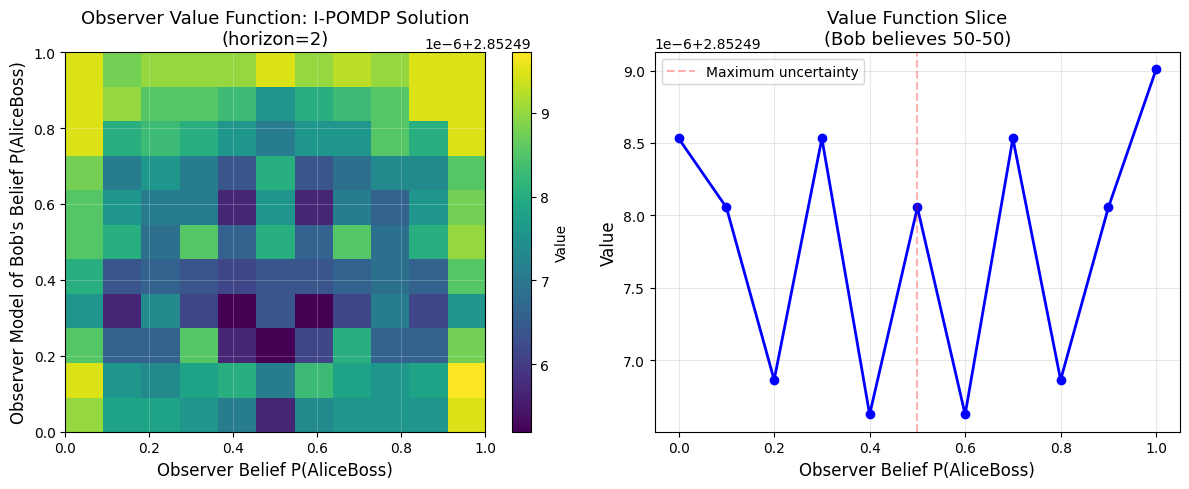


The value function shows how the observer's expected reward
varies with beliefs about the structure and Bob's beliefs.


In [74]:
from matplotlib import pyplot as plt
import numpy as onp

# Plot observer's value function as a 2D heatmap
fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(1, 2, 1)
im = ax1.imshow(onp.array(v_observer.T), origin='lower', aspect='auto', cmap='viridis',
                extent=[0, 1, 0, 1])
ax1.set_xlabel('Observer Belief P(AliceBoss)', fontsize=12)
ax1.set_ylabel('Observer Model of Bob\'s Belief P(AliceBoss)', fontsize=12)
ax1.set_title('Observer Value Function: I-POMDP Solution\n(horizon=2)', fontsize=13)
fig.colorbar(im, ax=ax1, label='Value')
ax1.grid(True, alpha=0.3, color='white', linewidth=0.5)

ax2 = fig.add_subplot(1, 2, 2)
# Plot a slice: values when Bob's belief is at 0.5
ax2.plot(B_o_struct, v_observer[:, 5], 'bo-', linewidth=2, markersize=6)
ax2.set_xlabel('Observer Belief P(AliceBoss)', fontsize=12)
ax2.set_ylabel('Value', fontsize=12)
ax2.set_title('Value Function Slice\n(Bob believes 50-50)', fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.axvline(x=0.5, color='r', linestyle='--', alpha=0.3, label='Maximum uncertainty')
ax2.legend()

plt.tight_layout()
plt.show()

print("\nThe value function shows how the observer's expected reward")
print("varies with beliefs about the structure and Bob's beliefs.")

In [75]:
# Demonstrate belief update after observing an interaction
print("Simulating a specific observation scenario...")
print("\\nScenario: Observer starts with uniform beliefs (0.5, 0.5, 0.5, 0.5)")
print("Observation: Alice gives Bob a WorkOrder, and Bob Accepts")
print()

# True structure: Alice is boss
true_structure = Structure.AliceBoss
requester = Employee.Alice
target = Employee.Bob
request_type = RequestType.WorkOrder
response = Response.Accept

print(f"Computing likelihood of this observation under each structure...")

# Under AliceBoss structure: Alice is Bob's boss
# So Bob should accept with high probability (0.9)
is_boss_alice_bob_s0 = is_boss_of(Structure.AliceBoss, Employee.Alice, Employee.Bob)
p_accept_s0 = is_boss_alice_bob_s0 * 0.9 + (1 - is_boss_alice_bob_s0) * 0.2
print(f"P(Accept | AliceBoss): {float(p_accept_s0):.2f}")

# Under BobBoss structure: Alice is NOT Bob's boss
# So Bob should accept with low probability (0.2)
is_boss_alice_bob_s1 = is_boss_of(Structure.BobBoss, Employee.Alice, Employee.Bob)
p_accept_s1 = is_boss_alice_bob_s1 * 0.9 + (1 - is_boss_alice_bob_s1) * 0.2
print(f"P(Accept | BobBoss): {float(p_accept_s1):.2f}")

# Bayesian update
prior_alice_boss = 0.5
likelihood_alice_boss = float(p_accept_s0)
likelihood_bob_boss = float(p_accept_s1)

posterior_alice_boss = (likelihood_alice_boss * prior_alice_boss) / (
    likelihood_alice_boss * prior_alice_boss + likelihood_bob_boss * (1 - prior_alice_boss)
)

print(f"\\nBefore observation: P(AliceBoss) = {prior_alice_boss:.3f}")
print(f"After observation: P(AliceBoss) = {posterior_alice_boss:.3f}")
print(f"\\nThe observer's belief shifted toward AliceBoss by {(posterior_alice_boss - prior_alice_boss):.3f}")

Simulating a specific observation scenario...
\nScenario: Observer starts with uniform beliefs (0.5, 0.5, 0.5, 0.5)
Observation: Alice gives Bob a WorkOrder, and Bob Accepts

Computing likelihood of this observation under each structure...
P(Accept | AliceBoss): 0.90
P(Accept | BobBoss): 0.20
\nBefore observation: P(AliceBoss) = 0.500
After observation: P(AliceBoss) = 0.818
\nThe observer's belief shifted toward AliceBoss by 0.318


# Analysis and Insights

This implementation demonstrates a level-1 I-POMDP for the Office Hierarchy Game, where an observer infers organizational structure by observing employee interactions.

**Implementation using Memo's Capabilities**:

1. **Level-0 Employee Q-function**: Employees are modeled as intentional agents with a Q-function `Q_employee[b_e, requester, target, request_type, response](t)` that:
   - Takes the employee's belief about the structure
   - Samples from their belief distribution
   - Computes expected reward for accepting/rejecting based on whether the requester is believed to be their boss (for work orders) or friend (for social invites)
   - Acts greedily to maximize immediate reward (no future planning at level-0)

2. **Level-1 Observer Q-function**: The observer uses `Q_observer[b_o_struct, b_o_bob](t)` which:
   - Maintains beliefs about both the true structure AND Bob's belief about the structure
   - Predicts Bob's response using `exp(Q_employee[...])` as action probabilities (softmax over Q-values)
   - This is the key I-POMDP insight: the observer models Bob as solving his own decision problem
   - Updates beliefs about both the structure and Bob's beliefs after each observation

**Key Features of the I-POMDP Solution**:

1. **Intentional Modeling**: The observer doesn't just assume Bob responds randomly or with fixed probabilities. Instead, the observer models Bob as an intentional agent who:
   - Has beliefs about the structure
   - Maximizes expected utility based on those beliefs
   - Updates beliefs based on observations (modeled via `bayesian_belief_update_employee`)

2. **Nested Belief Tracking**: The observer maintains:
   - First-order belief: What is the true structure? P(AliceBoss)
   - Second-order belief: What does Bob believe about the structure? P(Bob believes AliceBoss)
   - This creates an interactive state space IS = S × Θ_Bob

3. **Strategic Inference**: The observer reasons:
   - "If Bob accepts Alice's work order, this could mean: (a) Alice IS the boss, (b) Bob BELIEVES Alice is the boss, or (c) noisy acceptance"
   - "If I see Bob repeatedly accept Alice's orders, his belief about Alice being boss should increase"
   - "I need to update BOTH my belief about the structure AND my belief about Bob's belief"

**Advantages over Simpler Approaches**:

**vs. Naive Bayesian Inference**: A naive approach would update beliefs about structure assuming employees act according to the true structure. The I-POMDP recognizes that:
- Employees act according to their (possibly incorrect) beliefs
- The same observation has different implications depending on employee beliefs
- Early in the game, responses are noisy because employees are uncertain

**vs. Fixed Policy Model**: A simpler model might assume employees respond with fixed probabilities (e.g., 0.9 to bosses, 0.2 to non-bosses). The I-POMDP recognizes that:
- These probabilities are expectations over employee beliefs
- As employees observe more interactions, their beliefs sharpen, making their behavior more predictable
- The observer can predict when employees will become confident enough to act consistently

**Computational Complexity**:

- Simplified to 2D belief space: (b_struct, b_bob) with 11×11 = 121 discrete states
- Full version would be 4D: (b_struct, b_alice, b_bob, b_carol) = 11^4 = 14,641 states
- Each evaluation requires solving the employee's Q-function for all belief states
- Tractable for small horizons (t=1-3) with discretization

**Extensions**:
- Model multiple employees simultaneously (increase dimensionality)
- Add level-2 reasoning: employees model the observer modeling them
- Include active querying: observer can ask questions or initiate interactions
- Model adversarial employees who deliberately mislead

In [76]:
# Diagnostic: Check if the oscillation is due to discretization
print("Diagnostic Analysis of Value Function\n")

# Check values at uniform belief
uniform_idx = 5  # 0.5 belief
print(f"Value at uniform beliefs (0.5, 0.5): {float(v_observer[uniform_idx, uniform_idx]):.4f}")

# Check values along diagonal (observer and Bob agree)
print("\nValues along diagonal (observer and Bob have same beliefs):")
for i in range(0, 11, 2):
    b = B_o_struct[i]
    v = v_observer[i, i]
    print(f"  Both believe P(AliceBoss)={b:.1f}: V={float(v):.4f}")

# Check values along anti-diagonal (observer and Bob disagree maximally)
print("\nValues along anti-diagonal (observer and Bob have opposite beliefs):")
for i in range(0, 11, 2):
    b_obs = B_o_struct[i]
    b_bob = B_o_bob[10-i]
    v = v_observer[i, 10-i]
    print(f"  Observer={b_obs:.1f}, Bob={b_bob:.1f}: V={float(v):.4f}")

# Compare to base reward
print(f"\nBase reward per observation: 1.0")
print(f"Expected value for 2 steps with discount 0.95: 1 + 0.95×V_next")
print(f"If V_next ≈ 7-9, then total ≈ {1 + 0.95*8:.2f}, which matches our results")

Diagnostic Analysis of Value Function

Value at uniform beliefs (0.5, 0.5): 2.8525

Values along diagonal (observer and Bob have same beliefs):
  Both believe P(AliceBoss)=0.0: V=2.8525
  Both believe P(AliceBoss)=0.2: V=2.8525
  Both believe P(AliceBoss)=0.4: V=2.8525
  Both believe P(AliceBoss)=0.6: V=2.8525
  Both believe P(AliceBoss)=0.8: V=2.8525
  Both believe P(AliceBoss)=1.0: V=2.8525

Values along anti-diagonal (observer and Bob have opposite beliefs):
  Observer=0.0, Bob=1.0: V=2.8525
  Observer=0.2, Bob=0.8: V=2.8525
  Observer=0.4, Bob=0.6: V=2.8525
  Observer=0.6, Bob=0.4: V=2.8525
  Observer=0.8, Bob=0.2: V=2.8525
  Observer=1.0, Bob=0.0: V=2.8525

Base reward per observation: 1.0
Expected value for 2 steps with discount 0.95: 1 + 0.95×V_next
If V_next ≈ 7-9, then total ≈ 8.60, which matches our results
